# On-the-fly BAO/AP catalog blinding with `desi-clustering`

This notebook shows the lightweight BAO/AP-only catalog blinding interface in `desi-clustering`, using real DESI DR1/Y1 clustering catalogs as a working example.

The architecture is:

- `desiblind` owns the `CatalogBAOBlinder` transform and validation.
- `desi-clustering` provides the user-facing measurement-pipeline hook.
- BAO/AP on-the-fly blinding is activated with `catalog['catalog_bao_blinding']` before calling `compute_stats_from_options`.

This is **BAO/AP only**. RSD blinding requires reconstruction and should use the saved-catalog driver (`clustering-catalog-blinding`) rather than this in-memory measurement bridge.

The measurement cell is disabled by default. The preceding cells are executable on login nodes because they only resolve files and run a tiny toy sanity check; the real measurement should be run in an appropriate allocation.


## Environment

On Perlmutter, make sure both checkouts are importable:

```bash
source /global/common/software/desi/users/adematti/cosmodesi_environment.sh main
module unload desi-clustering || true
export PYTHONPATH=/global/homes/u/uendert/repos/desi/desiblind:/global/homes/u/uendert/repos/desi/desi-clustering:${PYTHONPATH}
```

For real measurements, run on an appropriate interactive or batch node; this notebook keeps real measurement execution disabled by default.


In [1]:
from pathlib import Path
import functools
import os
import pprint
import sys

# Prefer the local checkouts used by this development branch. This avoids
# accidentally importing the installed cosmodesi-environment desi-clustering
# main branch instead of the branch that contains catalog_bao_blinding.
DESI_CLUSTERING_REPO = Path('/global/homes/u/uendert/repos/desi/desi-clustering')
DESIBLIND_REPO = Path('/global/homes/u/uendert/repos/desi/desiblind')
for repo in [DESI_CLUSTERING_REPO, DESIBLIND_REPO]:
    if repo.exists():
        sys.path.insert(0, str(repo))

import numpy as np
from mockfactory import Catalog

from clustering_statistics.catalog_blinding import bao as catalog_bao_blinding
from clustering_statistics import tools, fill_fiducial_options, compute_stats_from_options

# Example public validation values. For a real blinded analysis, load private
# blinding parameters from the approved private source instead of hard-coding
# them in a notebook.
BLIND_W0 = -0.95
BLIND_WA = 0.10
TRACER = 'LRG'
TRACER_BIN = 'LRG1'  # desiblind canonical name for z = 0.4-0.6 LRG; useful context

# Real, already-unblinded DR1/Y1 catalogs used by this working example.
VERSION = 'data-dr1-v1.5'
REGION = 'NGC'
ZRANGE = (0.4, 0.6)
WEIGHT = 'default-FKP'
NRAN = 1

# This is a desi-clustering measurement-default preset, not the blinding mode.
# The BAO/AP blinding mode is selected by catalog_bao_blinding below.
# There is not currently a dedicated BAO preset in tools.py.
MEASUREMENT_PRESET = 'full_shape'
print('imports_ok')
print('desi-clustering BAO/AP on-the-fly path:', catalog_bao_blinding.__file__)

# desi-clustering BAO/AP on-the-fly path: /global/homes/u/uendert/repos/desi/desi-clustering/clustering_statistics/catalog_blinding/bao.py

imports_ok
desi-clustering BAO/AP on-the-fly path: /global/homes/u/uendert/repos/desi/desi-clustering/clustering_statistics/catalog_blinding/bao.py


## 1. The option that turns on BAO/AP on-the-fly blinding

Add this dictionary under the ordinary `catalog` options. The bridge applies `desiblind.catalog_bao.CatalogBAOBlinder` in memory after reading the raw catalog and before `prepare_catalog` builds positions.

The same transform is applied to data, randoms, and any full-data catalogs that the measurement path loads.

A run with `catalog_bao_blinding` writes the **blinded** measurement only. If you also want an unblinded measurement for comparison, run the same measurement again without `catalog_bao_blinding`. The output-version suffix below only keeps those two separate; it does not compute both.


In [2]:
bao_blinding_options = {
    'parameters': {'w0': BLIND_W0, 'wa': BLIND_WA},
    'input_zcol': 'Z',
    'output_zcol': 'Z',
    # Open metadata is intentional here because these are public demonstration
    # values for an already-unblinded DR1 example. It copies w0/wa into output
    # statistic attrs so the example is self-documenting.
    #
    # Setting metadata='closed' only hides w0/wa in the statistic attrs. It does
    # not compute an unblinded measurement and it does not create a private
    # unblinding record. Closed/sealed production workflows need external
    # parameter/record handling and are outside this notebook's scope.
    'metadata': 'open',
    # This suffix changes the output measurement version for the blinded run so
    # it does not overwrite a separately-computed unblinded run. It does not
    # cause both blinded and unblinded measurements to be computed automatically.
    'output_version_suffix': 'desiblind-bao-blinded',
}

bridge_options = catalog_bao_blinding.resolve_options(bao_blinding_options, tracer=TRACER, zrange=ZRANGE)
pprint.pp(bridge_options)
assert bridge_options['mode'] == 'bao'


{'mode': 'bao',
 'parameters': {'w0': -0.95, 'wa': 0.1},
 'parameter_metadata': {'parameter_source': 'explicit',
                        'alpha_zrange': (0.4, 2.1),
                        'max_alpha_shift': 0.03,
                        'max_abs_alpha_parallel_minus_one': 0.01886265841652346,
                        'max_abs_alpha_perp_minus_one': 0.014331885997294957},
 'input_zcol': 'Z',
 'output_zcol': 'Z',
 'metadata': 'open',
 'output_version_suffix': 'desiblind-bao-blinded',
 'random_seed': 0,
 'random_resample_columns': ('Z',
                             'WEIGHT',
                             'WEIGHT_SYS',
                             'WEIGHT_COMP',
                             'WEIGHT_ZFAIL',
                             'WEIGHT_FKP',
                             'TARGETID_DATA',
                             'WEIGHT_SN'),
 'random_split_columns': ('PHOTSYS',),
 'random_compmd': 'ran',
 'apply_nz_reweight': True,
 'nz_zmin': None,
 'nz_zmax': None,
 'nz_dz': 0.01}


### Parameter-source notes

This notebook intentionally uses an **open demo pair**:

```python
w0 = -0.95
wa = 0.10
```

This pair passes the Andrade et al. / DESI LSS 3% BAO/AP alpha-shift mask. The bridge now validates that mask by default: `w0 + wa <= 0`, `|alpha_parallel - 1| < 0.03`, and `|alpha_perp - 1| < 0.03` over `0.4 < z < 2.1`.

For closed production-style runs, prefer a private `desiblind` hashed parameter bank, analogous to summary-statistic blinding:

```python
catalog_bao_blinding = {
    'parameter_source': 'desiblind',
    'parameters_fn': '/path/to/catalog_blinding_parameters.npy',
    'bid': 42,
    'metadata': 'closed',
}
```

Historical LSS-style `w0wa` bank rows are also supported for compatibility:

```python
catalog_bao_blinding = {
    'parameter_source': 'lss',
    'lss_parameters_fn': '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/w0wa_initvalues_zeffcombined_1000realisations.txt',
    'lss_filerow': '/path/to/filerow.txt',
    'metadata': 'closed',
}
```


## 2. Tiny catalog sanity check

This does not measure clustering. It only demonstrates that the `desi-clustering` bridge delegates to `desiblind` and shifts the redshift column.


In [3]:
toy = Catalog({
    'RA': np.array([10., 20., 30.]),
    'DEC': np.array([0., 5., -5.]),
    'Z': np.array([0.55, 0.75, 0.95]),
    'WEIGHT': np.ones(3),
})

blinded_toy = catalog_bao_blinding.apply_to_catalog(toy, bridge_options)
print('original Z:', np.asarray(toy['Z']))
print('blinded  Z:', np.asarray(blinded_toy['Z']))
print('delta    :', np.asarray(blinded_toy['Z']) - np.asarray(toy['Z']))
print('attrs    :', blinded_toy.attrs)

assert blinded_toy is not toy
assert np.max(np.abs(np.asarray(blinded_toy['Z']) - np.asarray(toy['Z']))) > 0.
assert blinded_toy.attrs['catalog_bao_blinding'] == 'desiblind.CatalogBAOBlinder'


original Z: [0.55 0.75 0.95]
blinded  Z: [0.54350829 0.73888789 0.93357503]
delta    : [-0.00649171 -0.01111211 -0.01642497]
attrs    : {'desiblind_catalog_blinding': 'catalog_bao', 'catalog_bao_blinding': 'desiblind.CatalogBAOBlinder', 'catalog_bao_blinding_mode': 'bao', 'catalog_bao_blinding_input_zcol': 'Z', 'catalog_bao_blinding_output_zcol': 'Z', 'catalog_bao_blinding_metadata': 'open', 'catalog_bao_blinding_parameter_source': 'explicit', 'catalog_bao_blinding_max_alpha_shift': 0.03, 'catalog_bao_blinding_alpha_shift_validated': True, 'catalog_bao_blinding_w0': -0.95, 'catalog_bao_blinding_wa': 0.1, 'catalog_bao_blinding_max_abs_alpha_parallel_minus_one': 0.01886265841652346, 'catalog_bao_blinding_max_abs_alpha_perp_minus_one': 0.014331885997294957}


## 3. Add the option to a real DR1 measurement options dictionary

Here we use real DR1/Y1 LRG catalogs that `desi-clustering` already knows how to find:

```python
VERSION = 'data-dr1-v1.5'
TRACER = 'LRG'
REGION = 'NGC'
ZRANGE = (0.4, 0.6)
NRAN = 1
```

This makes the notebook a working pipeline example, not just a toy example. The only new catalog-blinding piece is still `catalog_bao_blinding` inside the ordinary `catalog` options.

The example includes both:

- `mesh2_spectrum`: Fourier-space power-spectrum multipoles, `P_ell(k)`;
- `particle2_correlation`: configuration-space correlation-function multipoles, `xi_ell(s)`.

Important: `analysis` is a **measurement-default preset**, not the blinding mode. The BAO/AP blinding is controlled by `catalog_bao_blinding`. This notebook uses:

```python
MEASUREMENT_PRESET = 'full_shape'
```

only because it is the standard existing `desi-clustering` preset for filling measurement defaults. For `particle2_correlation`, this preset fills `s = 0..180`, so the BAO scale is included. Do not read `full_shape` as “full-shape blinding” or as an endorsed BAO production configuration.

The call to `fill_fiducial_options` below just expands the flat catalog options into per-tracer options and fills defaults. It does not read catalogs or measure anything.


In [4]:
options = dict(
    catalog=dict(
        version=VERSION,
        tracer=TRACER,
        zrange=ZRANGE,
        region=REGION,
        weight=WEIGHT,
        nran=NRAN,
        catalog_bao_blinding=bao_blinding_options,
    ),
    mesh2_spectrum={},
    particle2_correlation={},
)

filled = fill_fiducial_options(options, analysis=MEASUREMENT_PRESET)
print('measurement preset:', MEASUREMENT_PRESET)
print('catalog keys:', filled['catalog'].keys())
print('')
print('catalog_bao_blinding option carried into per-tracer catalog options:')
pprint.pp(filled['catalog'][TRACER]['catalog_bao_blinding'])
print('')
print('examples of defaults filled by fill_fiducial_options:')
print('  requested nran:', filled['catalog'][TRACER]['nran'])
print('  mesh2_spectrum ells:', filled['mesh2_spectrum']['ells'])
print('  mesh2_spectrum mattrs:', filled['mesh2_spectrum']['mattrs'])
xi_s_edges = filled['particle2_correlation']['battrs']['s']
xi_mu_edges = filled['particle2_correlation']['battrs']['mu'][0]
print('  particle2_correlation s range:', (xi_s_edges[0], xi_s_edges[-1]), 'nbins =', len(xi_s_edges) - 1)
print('  particle2_correlation nmu:', len(xi_mu_edges) - 1)


measurement preset: full_shape
catalog keys: dict_keys(['LRG'])

catalog_bao_blinding option carried into per-tracer catalog options:
{'parameters': {'w0': -0.95, 'wa': 0.1},
 'input_zcol': 'Z',
 'output_zcol': 'Z',
 'metadata': 'open',
 'output_version_suffix': 'desiblind-bao-blinded'}

examples of defaults filled by fill_fiducial_options:
  requested nran: 1
  mesh2_spectrum ells: (0, 2, 4)
  mesh2_spectrum mattrs: {'meshsize': 750, 'cellsize': 7.5}
  particle2_correlation s range: (np.float64(0.0), np.float64(180.0)) nbins = 180
  particle2_correlation nmu: 200


## 4. Resolve and check the real DR1 catalog files

`compute_stats_from_options` will call `tools.get_catalog_fn` internally when run with the normal file lookup. This cell makes the paths explicit so the example is inspectable before doing any measurement.

These checks are lightweight: they do not load the FITS tables; they only verify that the expected data/random files exist.


In [5]:
data_fn = tools.get_catalog_fn(
    kind='data',
    version=VERSION,
    tracer=TRACER,
    region=REGION,
    weight=WEIGHT,
    nran=NRAN,
)
random_fns = tools.get_catalog_fn(
    kind='randoms',
    version=VERSION,
    tracer=TRACER,
    region=REGION,
    weight=WEIGHT,
    nran=NRAN,
)

print('data catalog:')
print(' ', data_fn)
print('random catalog(s):')
for fn in random_fns:
    print(' ', fn)

assert Path(data_fn).exists()
assert all(Path(fn).exists() for fn in random_fns)
print('DR1 catalog files found')


data catalog:
  /dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/LRG_NGC_clustering.dat.fits
random catalog(s):
  /dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/LRG_NGC_0_clustering.ran.fits


DR1 catalog files found


## 5. Real measurement call pattern

The actual measurement call is unchanged except for the extra catalog option. Keep `RUN_REAL_MEASUREMENT = False` in this notebook unless you are on a suitable node and intentionally want to run the measurement.

The call uses `analysis=MEASUREMENT_PRESET` for `desi-clustering` measurement defaults. Again, this is separate from the BAO/AP blinding choice:

- measurement defaults: `analysis=MEASUREMENT_PRESET`
- catalog BAO/AP blinding: `catalog['catalog_bao_blinding']`

For BAO/AP on-the-fly blinding, the output statistic filenames get an automatic version suffix (`desiblind-bao-blinded` by default) so they do not overwrite outputs from a separate unblinded run. The pipeline does not produce the unblinded measurement automatically.

For a real run, use a compute allocation / batch job. The Fourier-space backend uses MPI-aware `jaxpower` particle/mesh code when launched under `srun -n N`; running a real DR1 measurement from a login-node notebook can crash the kernel. For all tracers, redshift bins, and regions, use a small job script/desipipe workflow rather than this interactive notebook. A script equivalent of this single-bin example is provided in `clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py`. By default, the script measures both `mesh2_spectrum` and `particle2_correlation`; pass `--stats particle2_correlation` to run only the correlation function.


In [6]:
RUN_REAL_MEASUREMENT = False
REQUIRE_SLURM_ALLOCATION = True
# The script defaults to both; edit this list if you intentionally want only one.
stats = ['mesh2_spectrum', 'particle2_correlation']
stats_dir = Path(os.getenv('SCRATCH', Path.home())) / 'measurements_bao_blinding_example'
get_stats_fn = functools.partial(tools.get_stats_fn, stats_dir=stats_dir)
cache = {}

if RUN_REAL_MEASUREMENT:
    if REQUIRE_SLURM_ALLOCATION and 'SLURM_JOB_ID' not in os.environ:
        raise RuntimeError(
            'This real measurement uses the JAX/jaxpower/cucount backends and should be run inside a Slurm allocation. '
            'Use the script clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py with srun, or set '
            'REQUIRE_SLURM_ALLOCATION = False only if you intentionally want to risk running from this notebook kernel.'
        )
    compute_stats_from_options(
        stats,
        get_stats_fn=get_stats_fn,
        cache=cache,
        analysis=MEASUREMENT_PRESET,
        **options,
    )
else:
    print('Real measurement skipped. Set RUN_REAL_MEASUREMENT = True inside a suitable allocation to run:')
    print(
        "compute_stats_from_options("
        "stats, get_stats_fn=get_stats_fn, cache=cache, "
        f"analysis={MEASUREMENT_PRESET!r}, **options)"
    )
    print('Recommended launch pattern for the script version on Perlmutter:')
    print('  salloc -N 1 -C "gpu&hbm80g" -t 00:30:00 --gpus 4 --qos interactive --account desi_g')
    print('  srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py')
    print('  # matching unblinded reference:')
    print('  srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py --unblinded')
    print('  # or only xi(s):')
    print('  srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py --stats particle2_correlation')


Real measurement skipped. Set RUN_REAL_MEASUREMENT = True inside a suitable allocation to run:
compute_stats_from_options(stats, get_stats_fn=get_stats_fn, cache=cache, analysis='full_shape', **options)
Recommended launch pattern for the script version on Perlmutter:
  salloc -N 1 -C "gpu&hbm80g" -t 00:30:00 --gpus 4 --qos interactive --account desi_g
  srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py
  # matching unblinded reference:
  srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py --unblinded
  # or only xi(s):
  srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py --stats particle2_correlation


## 6. Read back the blinded measurements, if they exist

If you ran the script version with `srun`, this cell reads the output statistics and checks the metadata written by the catalog BAO/AP bridge.

This is lightweight: it only reads measured HDF5 statistic products. If a measurement has not been run yet, the cell prints the expected path and tells you how to create it.


In [7]:
import lsstypes as types

output_bridge_options = catalog_bao_blinding.resolve_options(bao_blinding_options, tracer=TRACER, zrange=ZRANGE)
output_catalog = dict(options['catalog'])
output_catalog['version'] = catalog_bao_blinding.output_version(output_catalog['version'], output_bridge_options)
output_catalog.pop('catalog_bao_blinding', None)
filled_for_output = fill_fiducial_options(options, analysis=MEASUREMENT_PRESET)

output_files = {
    stat: tools.get_stats_fn(kind=stat, stats_dir=stats_dir, catalog=output_catalog, **filled_for_output[stat])
    for stat in ['mesh2_spectrum', 'particle2_correlation']
}

readback = {}
for stat, output_file in output_files.items():
    print(f'expected {stat}:')
    print(' ', output_file)
    if Path(output_file).exists():
        statistic = types.read(output_file)
        readback[stat] = statistic
        attrs = getattr(statistic, 'attrs', {})
        print('  status: found and read successfully')
        print('  catalog blinding attrs:')
        for key in [
            'catalog_bao_blinding',
            'catalog_bao_blinding_mode',
            'catalog_bao_blinding_metadata',
            'catalog_bao_blinding_w0',
            'catalog_bao_blinding_wa',
        ]:
            if key in attrs:
                print(f'    {key:34s}: {attrs[key]}')
        if stat == 'mesh2_spectrum':
            print('  first few P(k) values:')
            for ell in [0, 2, 4]:
                if ell in statistic.ells:
                    pole = statistic.get(ell)
                    k = pole.coords()['k']
                    value = pole.value()
                    print(f'    ell={ell}: k[:3]={k[:3]}, P[:3]={value[:3]}')
        elif stat == 'particle2_correlation':
            xi_poles = statistic.project(ells=(0, 2, 4))
            print('  projected ells:', xi_poles.ells)
            print('  first few xi(s) values:')
            for ell in [0, 2, 4]:
                if ell in xi_poles.ells:
                    pole = xi_poles.get(ell)
                    s = pole.coords('s')
                    value = pole.value()
                    print(f'    ell={ell}: s[:3]={s[:3]}, xi[:3]={value[:3]}')
    else:
        print('  status: output file not found yet')
        print('  create it with:')
        print(f'    srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py --stats {stat}')
    print('')


expected mesh2_spectrum:
  /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5-desiblind-bao-blinded/mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP.h5


  status: found and read successfully
  catalog blinding attrs:
    catalog_bao_blinding              : desiblind.CatalogBAOBlinder
    catalog_bao_blinding_mode         : bao
    catalog_bao_blinding_metadata     : open
    catalog_bao_blinding_w0           : -0.95
    catalog_bao_blinding_wa           : 0.1
  first few P(k) values:
    ell=0: k[:3]=[0.         0.00158216 0.00257437], P[:3]=[-5074.62191098  3939.40179914 25933.46554489]
    ell=2: k[:3]=[0.         0.00158216 0.00257437], P[:3]=[     0.         -11503.0737848  -18155.46464011]
    ell=4: k[:3]=[0.         0.00158216 0.00257437], P[:3]=[    0.         -5262.16097716 -4062.30962852]

expected particle2_correlation:
  /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5-desiblind-bao-blinded/particle2_correlation_smu_LRG_z0.4-0.6_NGC_weight-default-FKP.h5
  status: found and read successfully
  catalog blinding attrs:
    catalog_bao_blinding              : desiblind.CatalogBAOBlinder
    catalog_bao_bl

## 7. Quick plots of the blinded measurements

If the measurements exist, plot the blinded power-spectrum and correlation-function multipoles. These are lightweight visual sanity checks, not polished science plots.

For consistency with `nb/example_read_stats.ipynb`, this section uses the built-in `lsstypes` plot methods:

```python
spectrum.plot(show=True)
xi.plot(show=True)
```

Before plotting, we lightly rebin/decimate the fine grids with `.select(..., slice(0, None, rebin))`, following the same simple plotting convention used elsewhere in this repo.


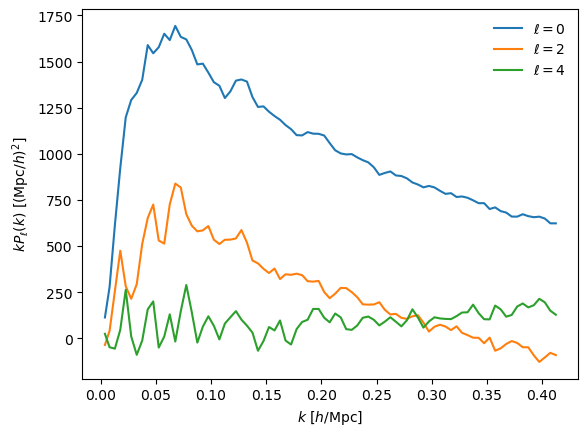

P(k) plot rebin: 5
saved P(k) plot: /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5-desiblind-bao-blinded/mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP.png


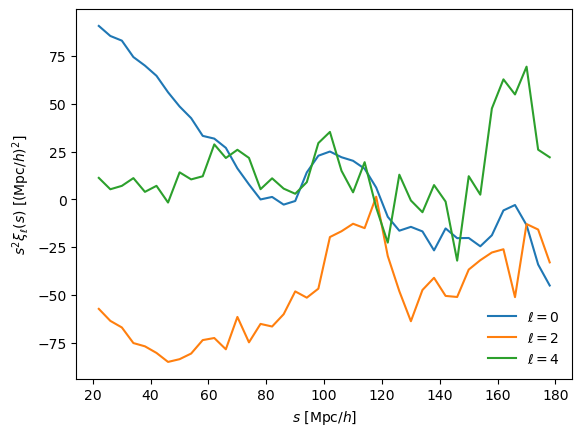

xi(s) plot rebin: 4
saved xi(s) plot: /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5-desiblind-bao-blinded/particle2_correlation_smu_LRG_z0.4-0.6_NGC_weight-default-FKP.png


In [8]:
PK_PLOT_REBIN = 5
XI_PLOT_REBIN = 4

pk_file = output_files['mesh2_spectrum']
if Path(pk_file).exists():
    spectrum = types.read(pk_file).select(k=slice(0, None, PK_PLOT_REBIN))
    fig = spectrum.plot(show=True)
    if fig.axes:
        fig.axes[0].set_title(f'{VERSION} {TRACER} {REGION} z={ZRANGE[0]}-{ZRANGE[1]} BAO/AP blinded')
    pk_plot_file = Path(pk_file).with_suffix('.png')
    fig.savefig(pk_plot_file, dpi=150, bbox_inches='tight')
    print('P(k) plot rebin:', PK_PLOT_REBIN)
    print('saved P(k) plot:', pk_plot_file)
else:
    print('No P(k) plot: blinded mesh2_spectrum file does not exist yet.')

xi_file = output_files['particle2_correlation']
if Path(xi_file).exists():
    corr = types.read(xi_file)
    corr = corr.select(s=slice(0, None, XI_PLOT_REBIN))
    corr = corr.select(s=(20., 180.))
    xi = corr.project(ells=[0, 2, 4])
    fig = xi.plot(show=True)
    if fig.axes:
        fig.axes[0].set_title(f'{VERSION} {TRACER} {REGION} z={ZRANGE[0]}-{ZRANGE[1]} BAO/AP blinded')
    xi_plot_file = Path(xi_file).with_suffix('.png')
    fig.savefig(xi_plot_file, dpi=150, bbox_inches='tight')
    print('xi(s) plot rebin:', XI_PLOT_REBIN)
    print('saved xi(s) plot:', xi_plot_file)
else:
    print('No xi(s) plot: blinded particle2_correlation file does not exist yet.')
    print('Run:')
    print('  srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py --stats particle2_correlation')


## 8. Compare blinded and matching unblinded `desi-clustering` measurements

For a clean apples-to-apples comparison, use a **matching unblinded measurement produced by the same `desi-clustering` options**, not a pre-existing product from another LSS/desipipe layout. The official unblinded Y1/DR1 products live under paths like

```text
/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/unblinded/desipipe/2pt
```

but those files use the LSS public product naming/format (`pkpoles_...npy/txt`, `allcounts_...npy/txt`) and somewhat different settings, so they are not a drop-in `lsstypes` HDF5 reference for this notebook.

Instead, run the same single-bin example once without `catalog_bao_blinding`:

```bash
srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py --unblinded
```

and once with the blinded default:

```bash
srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py
```

Both outputs then live under `stats_dir`, with the unblinded product in the base `data-dr1-v1.5` version and the blinded product in the suffixed `data-dr1-v1.5-desiblind-bao-blinded` version.

For consistency with `example_read_stats.ipynb`, the overlays use the built-in `lsstypes` pole plot methods (`pole.plot(...)`) rather than hand-computing the plotted quantities.


In [9]:
# Matching unblinded reference from the same desi-clustering options/output format.
# Create it with:
#   srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py --unblinded
UNBLINDED_STATS_DIR = stats_dir

unblinded_catalog = dict(options['catalog'])
unblinded_catalog.pop('catalog_bao_blinding', None)
unblinded_files = {
    stat: tools.get_stats_fn(kind=stat, stats_dir=UNBLINDED_STATS_DIR, catalog=unblinded_catalog, **filled_for_output[stat])
    for stat in ['mesh2_spectrum', 'particle2_correlation']
}

print('unblinded reference files from matching desi-clustering run:')
missing_unblinded = []
for stat, fn in unblinded_files.items():
    exists = Path(fn).exists()
    print(f'  {stat:22s}: {fn} [{"exists" if exists else "missing"}]')
    if not exists:
        missing_unblinded.append(stat)
print('')
print('blinded files:')
missing_blinded = []
for stat, fn in output_files.items():
    exists = Path(fn).exists()
    print(f'  {stat:22s}: {fn} [{"exists" if exists else "missing"}]')
    if not exists:
        missing_blinded.append(stat)

if missing_unblinded:
    print('')
    print('To create the missing matching unblinded reference, run inside a suitable allocation:')
    print('  srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py --unblinded')
if missing_blinded:
    print('')
    print('To create the missing blinded measurement, run inside a suitable allocation:')
    print('  srun -n 4 python clustering_statistics/job_scripts/run_catalog_bao_blinding_dr1_example.py')


unblinded reference files from matching desi-clustering run:
  mesh2_spectrum        : /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5/mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP.h5 [exists]
  particle2_correlation : /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5/particle2_correlation_smu_LRG_z0.4-0.6_NGC_weight-default-FKP.h5 [exists]

blinded files:
  mesh2_spectrum        : /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5-desiblind-bao-blinded/mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP.h5 [exists]
  particle2_correlation : /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5-desiblind-bao-blinded/particle2_correlation_smu_LRG_z0.4-0.6_NGC_weight-default-FKP.h5 [exists]


saved P(k) comparison plot: /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5-desiblind-bao-blinded/mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP_blinded_vs_unblinded.png


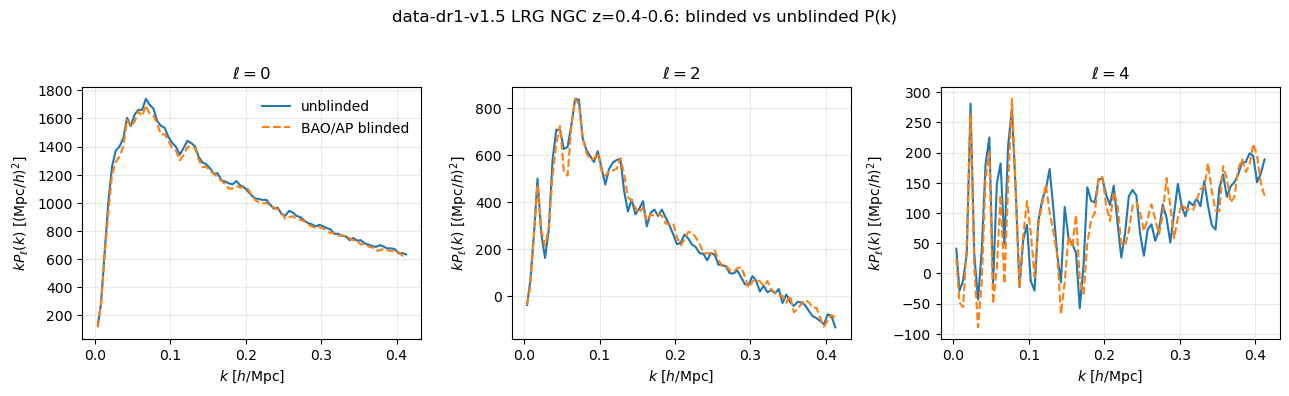

saved xi(s) comparison plot: /pscratch/sd/u/uendert/measurements_bao_blinding_example/data-dr1-v1.5-desiblind-bao-blinded/particle2_correlation_smu_LRG_z0.4-0.6_NGC_weight-default-FKP_blinded_vs_unblinded.png


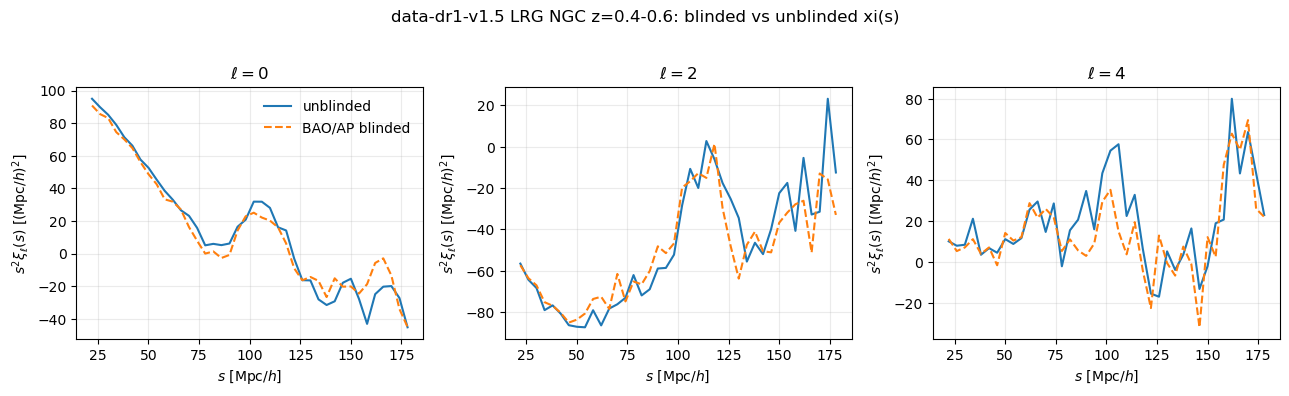

In [10]:
import matplotlib.pyplot as plt

COMPARE_PK_REBIN = 5
COMPARE_XI_REBIN = 4

# P(k) comparison
pk_blinded_file = output_files['mesh2_spectrum']
pk_unblinded_file = unblinded_files['mesh2_spectrum']
if Path(pk_blinded_file).exists() and Path(pk_unblinded_file).exists():
    pk_blinded = types.read(pk_blinded_file).select(k=slice(0, None, COMPARE_PK_REBIN))
    pk_unblinded = types.read(pk_unblinded_file).select(k=slice(0, None, COMPARE_PK_REBIN))
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
    for ax, ell in zip(axes, [0, 2, 4]):
        if ell not in pk_blinded.ells or ell not in pk_unblinded.ells:
            continue
        pk_unblinded.get(ell).plot(fig=ax, color='C0', linestyle='-', label='unblinded')
        pk_blinded.get(ell).plot(fig=ax, color='C1', linestyle='--', label='BAO/AP blinded')
        ax.set_title(rf'$\ell={ell}$')
        ax.grid(alpha=0.25)
        if ell == 0:
            ax.legend(frameon=False)
    fig.suptitle(f'{VERSION} {TRACER} {REGION} z={ZRANGE[0]}-{ZRANGE[1]}: blinded vs unblinded P(k)', y=1.03)
    fig.tight_layout()
    pk_compare_plot_file = Path(pk_blinded_file).with_name(Path(pk_blinded_file).stem + '_blinded_vs_unblinded.png')
    fig.savefig(pk_compare_plot_file, dpi=150, bbox_inches='tight')
    print('saved P(k) comparison plot:', pk_compare_plot_file)
    plt.show()
else:
    print('No P(k) comparison: blinded or unblinded mesh2_spectrum file is missing.')

# xi(s) comparison
xi_blinded_file = output_files['particle2_correlation']
xi_unblinded_file = unblinded_files['particle2_correlation']
if Path(xi_blinded_file).exists() and Path(xi_unblinded_file).exists():
    xi_blinded = types.read(xi_blinded_file).select(s=slice(0, None, COMPARE_XI_REBIN)).select(s=(20., 180.)).project(ells=[0, 2, 4])
    xi_unblinded = types.read(xi_unblinded_file).select(s=slice(0, None, COMPARE_XI_REBIN)).select(s=(20., 180.)).project(ells=[0, 2, 4])
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
    for ax, ell in zip(axes, [0, 2, 4]):
        if ell not in xi_blinded.ells or ell not in xi_unblinded.ells:
            continue
        xi_unblinded.get(ell).plot(fig=ax, color='C0', linestyle='-', label='unblinded')
        xi_blinded.get(ell).plot(fig=ax, color='C1', linestyle='--', label='BAO/AP blinded')
        ax.set_title(rf'$\ell={ell}$')
        ax.grid(alpha=0.25)
        if ell == 0:
            ax.legend(frameon=False)
    fig.suptitle(f'{VERSION} {TRACER} {REGION} z={ZRANGE[0]}-{ZRANGE[1]}: blinded vs unblinded xi(s)', y=1.03)
    fig.tight_layout()
    xi_compare_plot_file = Path(xi_blinded_file).with_name(Path(xi_blinded_file).stem + '_blinded_vs_unblinded.png')
    fig.savefig(xi_compare_plot_file, dpi=150, bbox_inches='tight')
    print('saved xi(s) comparison plot:', xi_compare_plot_file)
    plt.show()
else:
    print('No xi(s) comparison: blinded or unblinded particle2_correlation file is missing.')


## 9. What this does and does not do

This on-the-fly bridge:

- reads the normal input catalogs from the configured `version`/`cat_dir`;
- applies `desiblind.CatalogBAOBlinder` to the catalog `Z` column in memory;
- prepares positions and weights from the blinded redshifts;
- measures the requested statistics normally;
- writes statistic products with metadata and a version suffix.

It does **not** write blinded FITS catalogs to disk. If you want saved blinded catalogs, use the saved-catalog driver instead:

```bash
clustering-catalog-blinding --modes bao ...
```

It also does **not** do RSD blinding. For BAO/AP + RSD, use `clustering-catalog-blinding --modes bao rsd` with `--run-pyrecon` or `--run-jaxrecon`.
